Title: Assignment 6

Question 1: Create the following data set with 20 different years and perform the following operations using „dplyr‟ library.

In [39]:
# Question 1: Create the following data set with 20 different years and perform the following operations using „dplyr‟ library.
df <- data.frame(
  country = rep(c("India", "USA", "China", "Brazil", "UK", "Germany", "France", "Italy", "Canada", "Australia", 
                  "Japan", "South Korea", "Mexico", "South Africa", "Russia",
                  "Spain", "Netherlands", "Sweden", "Norway", "Denmark", "Finland", "Poland", "Portugal", 
                  "Argentina", "Chile", "Colombia", "New Zealand", "Thailand", "Vietnam", "Philippines"), each = 2),
  continent = rep(c("Asia", "North America", "Asia", "South America", "Europe", "Europe", "Europe", "Europe", "North America", "Oceania", 
                    "Asia", "Asia", "North America", "Africa", "Europe",
                    "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", 
                    "South America", "South America", "South America", "Oceania", "Asia", "Asia", "Asia"), each = 2),
  year = rep(2000:2014, times = 2),
  lifeExp = runif(60, 60, 85), 
  pop = sample(1e6:1.4e9, 60, replace = TRUE),
  gdpPerc = sample(3000:60000, 60, replace = TRUE)
)

print(summary(df))

   country           continent              year         lifeExp     
 Length:60          Length:60          Min.   :2000   Min.   :60.70  
 Class :character   Class :character   1st Qu.:2003   1st Qu.:66.18  
 Mode  :character   Mode  :character   Median :2007   Median :72.05  
                                       Mean   :2007   Mean   :72.70  
                                       3rd Qu.:2011   3rd Qu.:79.22  
                                       Max.   :2014   Max.   :84.61  
      pop               gdpPerc     
 Min.   :5.415e+06   Min.   : 3473  
 1st Qu.:2.802e+08   1st Qu.:16417  
 Median :6.557e+08   Median :29212  
 Mean   :6.931e+08   Mean   :31027  
 3rd Qu.:1.121e+09   3rd Qu.:48041  
 Max.   :1.385e+09   Max.   :59563  


Question 1. (a): How many unique countries per continent.

In [40]:
library(dplyr)

unique_countries <- select(df, country, continent)
unique_countries <- unique(unique_countries)

print(count(group_by(unique_countries, continent)))

# A tibble: 6 × 2
# Groups:   continent [6]
  continent         n
  <chr>         <int>
1 Africa            1
2 Asia              7
3 Europe           13
4 North America     3
5 Oceania           2
6 South America     4


Question 1. (b): Which European nation had the lowest GDP per capita in a given year?

In [41]:
lowest_gdp_europe <- df %>%
  filter(continent == "Europe") %>%
  group_by(year) %>%
  select(country, year, gdpPerc) %>%
  arrange(gdpPerc) %>%
  slice(1)

print(lowest_gdp_europe)

# A tibble: 15 × 3
# Groups:   year [15]
   country      year gdpPerc
   <chr>       <int>   <int>
 1 Spain        2000    4557
 2 Spain        2001    3473
 3 Netherlands  2002   29723
 4 Netherlands  2003   51904
 5 Sweden       2004   20726
 6 Sweden       2005   14257
 7 Norway       2006   22748
 8 Norway       2007   29089
 9 UK           2008   46764
10 UK           2009   16437
11 Germany      2010   21592
12 Finland      2011   12188
13 France       2012    7286
14 Poland       2013   22371
15 Italy        2014   33837


Question 1. (c): According to the data available, what was the average life expectancy across each continent in a given year?

In [42]:
avg_life_exp <- aggregate(lifeExp ~ continent + year, data = df, FUN = mean)
print(avg_life_exp)

       continent year  lifeExp
1           Asia 2000 65.14252
2         Europe 2000 79.77786
3           Asia 2001 69.45240
4         Europe 2001 75.19503
5  North America 2001 62.17573
6  South America 2001 79.79695
7         Europe 2002 78.07430
8  North America 2002 70.81142
9  South America 2002 67.99683
10        Europe 2003 70.62622
11 North America 2003 64.56915
12       Oceania 2003 80.82504
13 South America 2003 77.96354
14          Asia 2004 65.75751
15        Europe 2004 62.46553
16       Oceania 2004 84.40349
17 South America 2004 76.05859
18          Asia 2005 71.06184
19        Europe 2005 79.09840
20 South America 2005 73.18669
21          Asia 2006 67.92235
22        Europe 2006 60.83113
23 South America 2006 75.07079
24          Asia 2007 80.78442
25        Europe 2007 64.97082
26       Oceania 2007 82.87211
27 South America 2007 73.76068
28          Asia 2008 64.17261
29        Europe 2008 73.44874
30       Oceania 2008 64.82378
31          Asia 2009 72.02148
32      

Question 1. (d): What 5 countries have the highest total GDP over all years combined?

In [43]:
gdp_df <- df %>%
  mutate(total_gdp = as.numeric(gdpPerc) * as.numeric(pop))

top_5_countries <- aggregate(total_gdp ~ country, data = gdp_df, FUN = sum) %>%
  arrange(desc(total_gdp)) %>%
  head(5)
print(top_5_countries)

      country    total_gdp
1     Vietnam 1.184799e+14
2   Argentina 8.315225e+13
3 Philippines 7.778463e+13
4          UK 7.159192e+13
5    Portugal 6.638363e+13


Question 1. (e): What countries and years had life expectancies of at least 80 years?

In [44]:
high_life_exp <- df %>%
  filter(lifeExp >= 80) %>%
  select(country, year, lifeExp)

print(high_life_exp)

       country year  lifeExp
1        Italy 2014 82.23454
2        Italy 2000 82.73717
3    Australia 2003 80.82504
4    Australia 2004 84.40349
5  South Korea 2007 80.78442
6      Denmark 2009 83.00453
7      Finland 2010 84.60847
8       Poland 2013 82.66266
9     Portugal 2000 82.89337
10    Colombia 2006 83.81720
11 New Zealand 2007 82.87211
12    Thailand 2010 80.20809
13     Vietnam 2011 83.38570


Question 1. (f): What 10 countries have the strongest correlation (in either direction) between life expectancy and per capita GDP?

In [45]:
df <- mutate(df, gdpCorr = cor(gdpPerc, lifeExp))
df <- group_by(df, country) %>%
        arrange(desc(abs(gdpCorr))) %>%
        slice(1)
print(tail(df, 10))

# A tibble: 10 × 7
# Groups:   country [10]
   country      continent      year lifeExp        pop gdpPerc gdpCorr
   <chr>        <chr>         <int>   <dbl>      <int>   <int>   <dbl>
 1 Portugal     Europe         2014    60.7  745176895   49615  0.0548
 2 Russia       Europe         2013    70.4 1155678846   48803  0.0548
 3 South Africa Africa         2011    61.0  191807960   59563  0.0548
 4 South Korea  Asia           2007    80.8  271126592   25492  0.0548
 5 Spain        Europe         2000    73.7  703609753    4557  0.0548
 6 Sweden       Europe         2004    62.5  599908828   20726  0.0548
 7 Thailand     Asia           2009    72.0 1323608181   17857  0.0548
 8 UK           Europe         2008    67.3 1044084857   46764  0.0548
 9 USA          North America  2002    70.5  480942926    6634  0.0548
10 Vietnam      Asia           2011    83.4 1275956968   47688  0.0548


Question 1. (g): Which combinations of continent (besides Asia) and year have the highest average population across all countries?

In [46]:
mutate(gdp_df, corr = lifeExp/gdpPerc)
top_10_corr <- aggregate(corr ~ country, data = gdp_df, FUN = function(x) cor(x, use = "complete.obs")) %>%
  arrange(desc(abs(corr))) %>%

print(head(top_10_corr, 10))

country,continent,year,lifeExp,pop,gdpPerc,total_gdp,corr
<chr>,<chr>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
India,Asia,2000,65.14252,284962683,54235,1.545495e+13,0.001201116
India,Asia,2001,69.45240,5414935,23008,1.245868e+11,0.003018619
USA,North America,2002,70.47504,480942926,6634,3.190575e+12,0.010623311
USA,North America,2003,64.56915,1087713270,48496,5.274974e+13,0.001331432
China,Asia,2004,65.75751,194423274,26530,5.158049e+12,0.002478610
China,Asia,2005,79.04312,1327835934,10056,1.335272e+13,0.007860294
Brazil,South America,2006,66.32439,62002692,39874,2.472295e+12,0.001663349
Brazil,South America,2007,73.76068,516667082,16356,8.450607e+12,0.004509702
UK,Europe,2008,67.32279,1044084857,46764,4.882558e+13,0.001439628


ERROR: Error in eval(predvars, data, env): object 'corr' not found


Question 1. (h): Which three countries have had the most consistent population estimates (i.e. lowest standard deviation) across the years of available data?

In [9]:
consistent_pop <- aggregate(pop ~ country, data = df, FUN = sd) %>%
  arrange(pop) %>%
  head(3)

print(consistent_pop)

   country      pop
1 Colombia 54288358
2    Italy 56259522
3    Spain 66233896


Question 1. (i): Excluding records from a given year, which observations indicate that the population of a country has decreased from the previous year and the life expectancy has increased?

In [10]:
pop_life_change <- df %>%
  arrange(country, year) %>%
  mutate(pop_change = pop - lag(pop),
	 lifeExp_change = lifeExp - lag(lifeExp)) %>%
  filter(pop_change < 0 & lifeExp_change > 0) %>%
  select(country, year, pop, lifeExp)

print(pop_life_change)

       country year        pop  lifeExp
1       Canada 2001 1098332980 73.65992
2        Chile 2004  433846660 76.11699
3        Italy 2000   96648284 64.89747
4        Italy 2014   17085305 66.93329
5  New Zealand 2008  310396056 83.27340
6       Norway 2007   47326946 62.27509
7       Poland 2012  626124108 68.10699
8       Poland 2013  366215442 78.07017
9       Sweden 2005  251534840 75.01433
10          UK 2009  511749811 70.22766
11         USA 2003    7297079 83.67314


Question 2: Create a database file “DataSet.csv” that contains 10 records of medicine with attribute : MedID, Med_Name, Company, Manf_year, Exp_date, Quantity_in_stock, Sales.

In [11]:
df <- data.frame(
  medid = 1:10,
  med_name = c("meda", "medb", "medc", "medd", "mede", "medf", "medg", "medh", "medi", "medj"),
  company = c("comp1", "comp2", "comp1", "comp3", "comp2", "comp4", "comp3", "comp1", "comp4", "comp2"),
  manf_year = c(2018, 2019, 2018, 2020, 2019, 2021, 2020, 2018, 2021, 2019),
  exp_date = as.Date(trimws(iconv(c("2023-12-31", "2024-06-30", "2023-11-30", 
                                    "2025-01-31", "2024-05-31", "2026-12-31", 
                                    "2025-03-31", "2023-10-31", "2026-11-30", "2024-07-31"),
                                  from = "", to = "UTF-8"))),
  quantity_in_stock = c(100, 150, 200, 120, 180, 160, 140, 130, 170, 110),
  sales = c(5000, 7000, 6000, 8000, 7500, 9000, 8500, 6500, 9500, 7200)
)
print(df)
write.csv("DataSet.csv", row.names=FALSE)

   medid med_name company manf_year   exp_date quantity_in_stock sales
1      1     meda   comp1      2018 2023-12-31               100  5000
2      2     medb   comp2      2019 2024-06-30               150  7000
3      3     medc   comp1      2018 2023-11-30               200  6000
4      4     medd   comp3      2020 2025-01-31               120  8000
5      5     mede   comp2      2019 2024-05-31               180  7500
6      6     medf   comp4      2021 2026-12-31               160  9000
7      7     medg   comp3      2020 2025-03-31               140  8500
8      8     medh   comp1      2018 2023-10-31               130  6500
9      9     medi   comp4      2021 2026-11-30               170  9500
10    10     medj   comp2      2019 2024-07-31               110  7200
"x"
"DataSet.csv"


Question 2. (a): Read the data file and show the first 4 record of the file.

In [22]:
data <- read.csv("DataSet.csv")
print(head(data, 4))

  MedID Med_Name Company Manf_year   Exp_date Quantity_in_stock Sales
1     1     MedA   Comp1      2018 2023-12-31               100  5000
2     2     MedB   Comp2      2019 2024-06-30               150  7000
3     3     MedC   Comp1      2018 2023-11-30               200  6000
4     4     MedD   Comp3      2020 2025-01-31               120  8000


Question 2. (b): Read the data file and show the last 4 record of the file.

In [23]:
print(tail(data, 4))

   MedID Med_Name Company Manf_year   Exp_date Quantity_in_stock Sales
7      7     MedG   Comp3      2020 2025-03-31               140  8500
8      8     MedH   Comp1      2018 2023-10-31               130  6500
9      9     MedI   Comp4      2021 2026-11-30               170  9500
10    10     MedJ   Comp2      2019 2024-07-31               110  7200


Question 2. (c): Find the coorelation between Quantity_in_stock and Exp_date.

In [26]:
print(data$Exp_date)
data$Exp_date <- as.numeric(data$Exp_date)
# data <- na.omit(data)
# correlation <- cor(data$Quantity_in_stock, data$Exp_date)
# print(correlation)

 [1] "2023-12-31" "2024-06-30" "2023-11-30" "2025-01-31" "2024-05-31"
 [6] "2026-12-31" "2025-03-31" "2023-10-31" "2026-11-30" "2024-07-31"


Warning message:
“NAs introduced by coercion”


Question 2. (d): Plot the bar graph for the Sales with year of manufacturing.

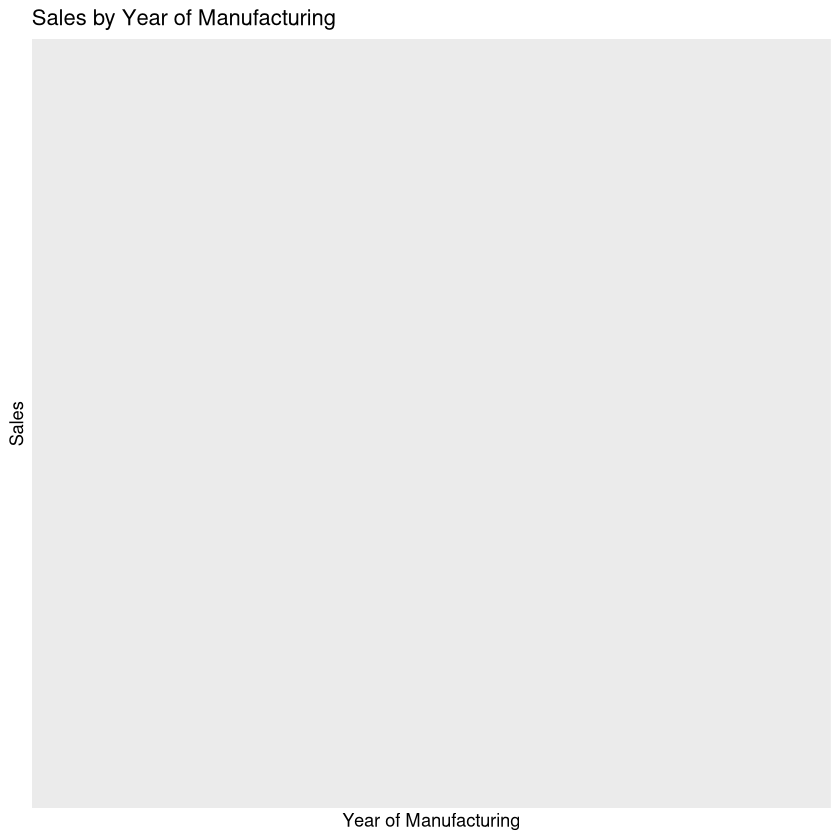

In [17]:
library(ggplot2)
ggplot(data, aes(x = Manf_year, y = Sales)) +
geom_bar(stat = "identity", fill = "blue") +
labs(
  title = "Sales by Year of Manufacturing",
  x = "Year of Manufacturing",
  y = "Sales"
)

Question 2. (e): Find the company having more than one type of medicine.

In [38]:
company_medicine <- aggregate(Med_Name ~ Company, data = data, FUN = function(x) length(unique(x)))
print(company_medicine[company_medicine$Med_Name > 1, ])

  Company Med_Name
1   Comp1        3
2   Comp2        3
3   Comp3        2
4   Comp4        2


Question 2. (f): Find the type of Medicine available.

In [40]:
medicine_types <- unique(data$Med_Name)
print(medicine_types)

 [1] "MedA" "MedB" "MedC" "MedD" "MedE" "MedF" "MedG" "MedH" "MedI" "MedJ"


Question 2. (g): Which medicines are expiring? Show by box plots.

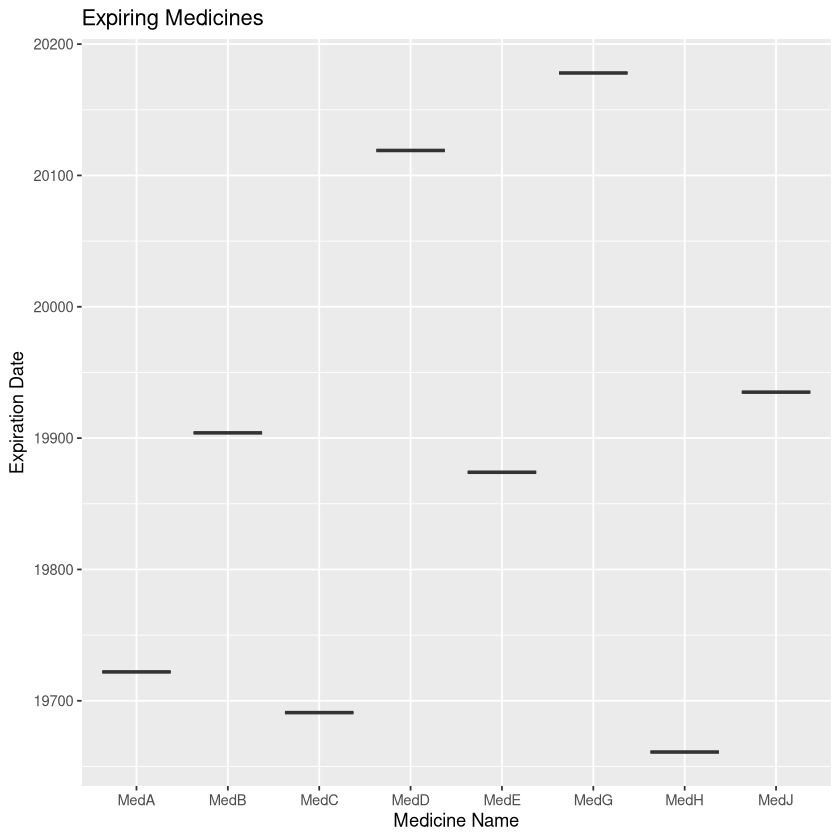

In [42]:
expiring_medicines <- data[data$Exp_date < Sys.Date(), ]
ggplot(expiring_medicines, aes(x = Med_Name, y = Exp_date)) +
  geom_boxplot(fill = "orange") +
  labs(title = "Expiring Medicines", x = "Medicine Name", y = "Expiration Date")

Question 2. (h): Find the average stock in the store.

In [44]:
average_stock <- mean(data$Quantity_in_stock)
print(average_stock)

average_stock_per_med <- aggregate(Quantity_in_stock ~ Med_Name, data = data, FUN = mean)
print(average_stock_per_med)

[1] 146
   Med_Name Quantity_in_stock
1      MedA               100
2      MedB               150
3      MedC               200
4      MedD               120
5      MedE               180
6      MedF               160
7      MedG               140
8      MedH               130
9      MedI               170
10     MedJ               110


Question 2. (i): Draw the regression line between Manufacturing year and Sales.

`geom_smooth()` using formula = 'y ~ x'


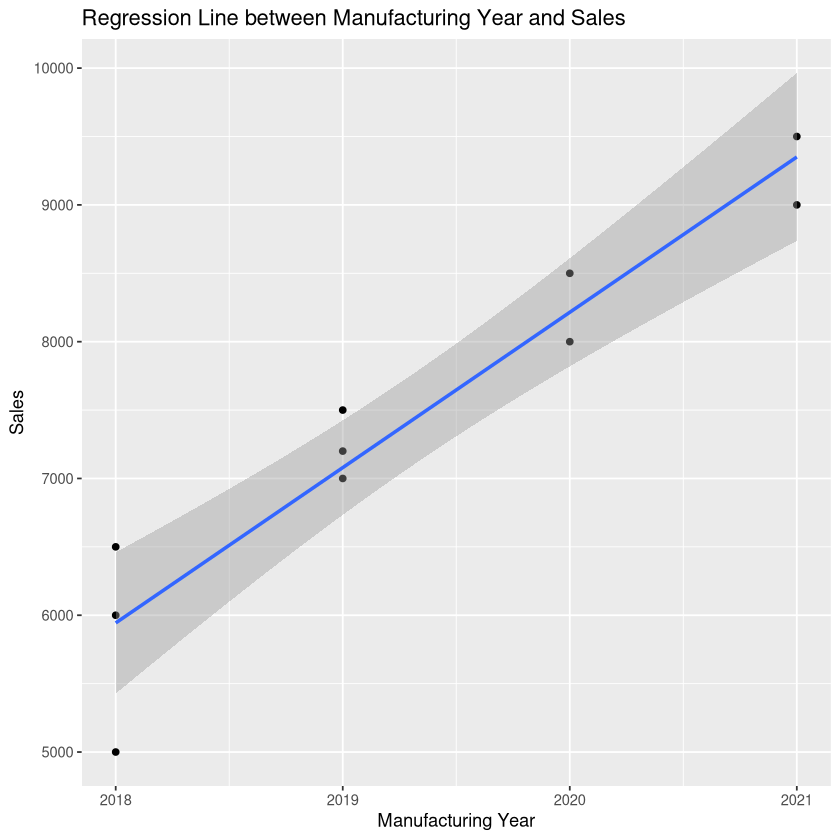

In [45]:
ggplot(data, aes(x = Manf_year, y = Sales)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(title = "Regression Line between Manufacturing Year and Sales", x = "Manufacturing Year", y = "Sales")